In [1]:
import os
import torch
from torchvision import transforms, datasets
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt
import numpy as np

## Load MNIST 

In [2]:
transforms = transforms.Compose([
    transforms.ToTensor(),
    # transforms.Normalize((0.5,), (0.5,))
])

train_dataset = datasets.MNIST(root='../data', train=True, transform=transforms, download=True)
test_dataset = datasets.MNIST(root='../data', train=False, transform=transforms, download=True)

In [3]:
train_loader = DataLoader(dataset=train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(dataset=test_dataset, batch_size=32, shuffle=False)

In [4]:
train_dataset, test_dataset

(Dataset MNIST
     Number of datapoints: 60000
     Root location: ../data
     Split: Train
     StandardTransform
 Transform: Compose(
                ToTensor()
            ),
 Dataset MNIST
     Number of datapoints: 10000
     Root location: ../data
     Split: Test
     StandardTransform
 Transform: Compose(
                ToTensor()
            ))

## Number of data samples

In [5]:
print(f'Number of training samples: {len(train_dataset)}')
print(f'Number of test samples: {len(test_dataset)}')
print(f'Total number of samples: {len(train_dataset) + len(test_dataset)}')

Number of training samples: 60000
Number of test samples: 10000
Total number of samples: 70000


## Min max value in the dataset

In [6]:
i = 0
for images, labels in train_loader:
    print(f'Image pixel range: {images.min().item()} - {images.max().item()}')
    print(f'Label range: {labels.min().item()} - {labels.max().item()}\n')
    i += 1
    if i == 10:
        break

Image pixel range: 0.0 - 1.0
Label range: 0 - 9

Image pixel range: 0.0 - 1.0
Label range: 0 - 9

Image pixel range: 0.0 - 1.0
Label range: 0 - 9

Image pixel range: 0.0 - 1.0
Label range: 0 - 9

Image pixel range: 0.0 - 1.0
Label range: 0 - 9

Image pixel range: 0.0 - 1.0
Label range: 0 - 9

Image pixel range: 0.0 - 1.0
Label range: 0 - 9

Image pixel range: 0.0 - 1.0
Label range: 0 - 9

Image pixel range: 0.0 - 1.0
Label range: 0 - 9

Image pixel range: 0.0 - 1.0
Label range: 0 - 9



## Data dimension

In [7]:
i = 0
for images, labels in train_loader:
    print(f'Image tensor dimensions: {images.shape}')
    print(f'Label tensor dimensions: {labels.shape}\n')
    i += 1
    if i == 10:
        break


Image tensor dimensions: torch.Size([32, 1, 28, 28])
Label tensor dimensions: torch.Size([32])

Image tensor dimensions: torch.Size([32, 1, 28, 28])
Label tensor dimensions: torch.Size([32])

Image tensor dimensions: torch.Size([32, 1, 28, 28])
Label tensor dimensions: torch.Size([32])

Image tensor dimensions: torch.Size([32, 1, 28, 28])
Label tensor dimensions: torch.Size([32])

Image tensor dimensions: torch.Size([32, 1, 28, 28])
Label tensor dimensions: torch.Size([32])

Image tensor dimensions: torch.Size([32, 1, 28, 28])
Label tensor dimensions: torch.Size([32])

Image tensor dimensions: torch.Size([32, 1, 28, 28])
Label tensor dimensions: torch.Size([32])

Image tensor dimensions: torch.Size([32, 1, 28, 28])
Label tensor dimensions: torch.Size([32])

Image tensor dimensions: torch.Size([32, 1, 28, 28])
Label tensor dimensions: torch.Size([32])

Image tensor dimensions: torch.Size([32, 1, 28, 28])
Label tensor dimensions: torch.Size([32])



Each image dimension has a shape of (1, 28, 28), where channel is 1 (since it's only black and white, or in gray scale), and the height and width are 28. Additionally, batch dimension is usually the first dimension of the tensor, which is 32 in this case since batch size is 32.

For label, its dimension is 1 since it will represent the digit of the corresponding image

## Missing data

In [13]:
def is_missing(loader):
    for images, labels in loader:
        if torch.isnan(images).any() or torch.isnan(labels).any():
            return True
    return False

print(f'Missing values in training set: {is_missing(train_loader)}')
print(f'Missing values in test set: {is_missing(test_loader)}')

Missing values in training set: False
Missing values in test set: False


Therefore, there's no missing information in this dataset

## Label

In [9]:
train_dataset.targets.unique(), test_dataset.targets.unique()

(tensor([0, 1, 2, 3, 4, 5, 6, 7, 8, 9]),
 tensor([0, 1, 2, 3, 4, 5, 6, 7, 8, 9]))

Labels for this dataset are the digits from 0 to 9

## Split

In [10]:
train_size = int(0.8 * len(train_dataset))
val_size = len(train_dataset) - train_size
train_data, val_data = random_split(train_dataset, [train_size, val_size])

In [11]:
print(f'Number of training samples: {len(train_data)}')
print(f'Number of validation samples: {len(val_data)}')
print(f'Number of test samples: {len(test_dataset)}')

Number of training samples: 48000
Number of validation samples: 12000
Number of test samples: 10000


## Visualize

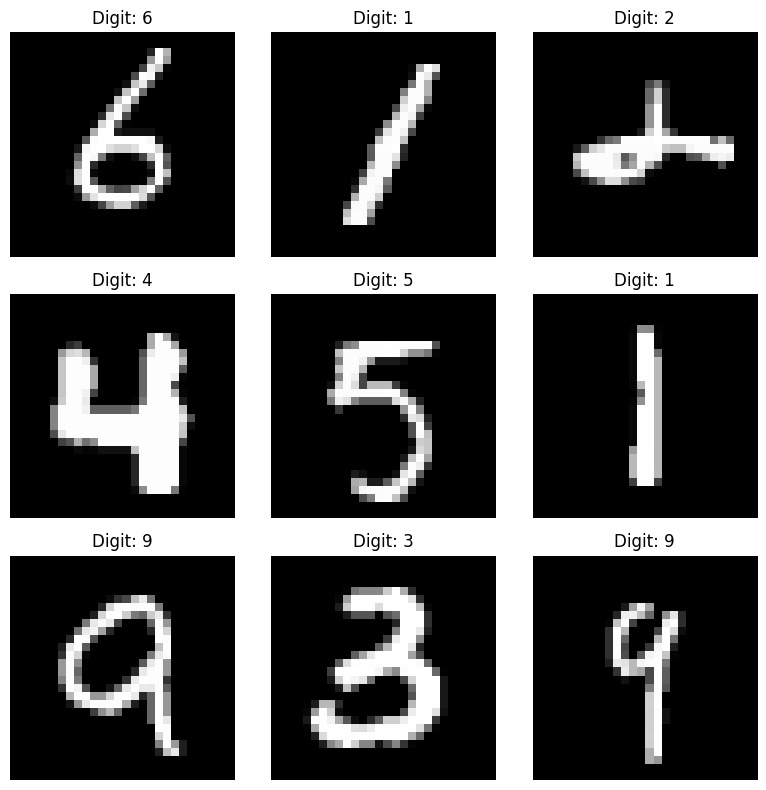

In [20]:
def visualize(loader, num_images=9):
    fig, axes = plt.subplots(num_images // 3, 3, figsize=(8, 8))
    axes = axes.flatten()
    for i in range(num_images):
        images, labels = next(iter(loader)) # (batch, Channel, Height, Width)
        axes[i].imshow(images[i].squeeze(), cmap='gray')
        axes[i].set_title(f'Digit: {labels[i].item()}')
        axes[i].axis('off')
    plt.tight_layout()
    plt.show()

visualize(train_loader)

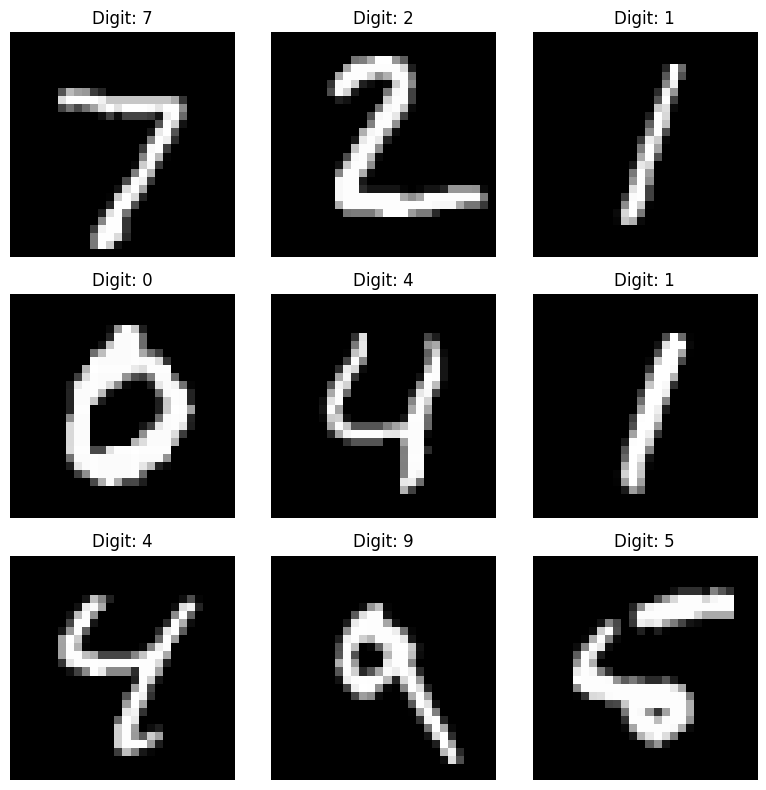

In [21]:
visualize(test_loader)